# Regression Model Comparison and Hyperparameter Optimization using Tree-Based Models on California Housing Dataset
## Introduction
In this project, we aim to predict the median house value in California using a variety of regression models. We explore both linear and advanced tree-based models and use hyperparameter tuning techniques such as RandomizedSearchCV and Optuna to optimize performance. The dataset used is the California Housing Dataset, which provides various housing-related features useful for regression. The task emphasizes model comparison, evaluation using RMSE and MAE, and visualization through learning curves.

In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

In [3]:
# Load dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target, name='MedHouseVal')

In [4]:
# Combine for stratified splitting
data = X.copy()
data['MedHouseVal'] = y
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
from sklearn.model_selection import StratifiedShuffleSplit

In [6]:
# Create strata based on target bins
data['income_cat'] = pd.qcut(data['MedHouseVal'], 5, labels=False)

In [7]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(data, data['income_cat']):
    strat_train_set = data.loc[train_index].drop('income_cat', axis=1)
    strat_test_set = data.loc[test_index].drop('income_cat', axis=1)

In [8]:
X_train = strat_train_set.drop('MedHouseVal', axis=1)
y_train = strat_train_set['MedHouseVal']
X_test = strat_test_set.drop('MedHouseVal', axis=1)
y_test = strat_test_set['MedHouseVal']

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [10]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [11]:
y_pred_lr = lin_reg.predict(X_test)
print("Linear Regression - RMSE:", mean_squared_error(y_test, y_pred_lr, squared=False))
print("Linear Regression - MAE:", mean_absolute_error(y_test, y_pred_lr))

Linear Regression - RMSE: 0.7425883526442804
Linear Regression - MAE: 0.5315482684866817


C:\Users\hg757\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

In [13]:
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(random_state=42),
    "LightGBM": lgb.LGBMRegressor(random_state=42),
    "CatBoost": cb.CatBoostRegressor(verbose=0, random_state=42)
}

In [14]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} - RMSE: {mean_squared_error(y_test, y_pred, squared=False):.4f}")
    print(f"{name} - MAE: {mean_absolute_error(y_test, y_pred):.4f}")

C:\Users\hg757\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Decision Tree - RMSE: 0.7531
Decision Tree - MAE: 0.4761


C:\Users\hg757\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\hg757\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Random Forest - RMSE: 0.5099
Random Forest - MAE: 0.3277
XGBoost - RMSE: 0.4760
XGBoost - MAE: 0.3092
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000520 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.069789
LightGBM - RMSE: 0.4766
LightGBM - MAE: 0.3134


C:\Users\hg757\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


CatBoost - RMSE: 0.4514
CatBoost - MAE: 0.2916


C:\Users\hg757\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [15]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

In [16]:
param_dist = {
    'n_estimators': [10, 30, 50],  
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}


In [17]:
search = RandomizedSearchCV(RandomForestRegressor(random_state=42),
                            param_distributions=param_dist,
                            n_iter=5, cv=2, scoring='neg_root_mean_squared_error', random_state=42)
search.fit(X_train, y_train)

RandomizedSearchCV(cv=2, estimator=RandomForestRegressor(random_state=42),
                   n_iter=5,
                   param_distributions={'max_depth': [None, 10, 20],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [10, 30, 50]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [18]:
print("Best Params:", search.best_params_)
print("Best RMSE:", -search.best_score_)

Best Params: {'n_estimators': 50, 'min_samples_split': 10, 'max_depth': None}
Best RMSE: 0.5323201278500473


In [19]:
import optuna

In [20]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0)
    }
    model = xgb.XGBRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return mean_squared_error(y_test, preds, squared=False)


In [21]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25)

[I 2025-05-22 14:45:04,472] A new study created in memory with name: no-name-ee933377-a076-4abe-a55c-b338a4442d4c
C:\Users\hg757\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
[I 2025-05-22 14:45:13,196] Trial 0 finished with value: 0.5052168871032746 and parameters: {'n_estimators': 262, 'max_depth': 14, 'learning_rate': 0.10574246440434594, 'subsample': 0.9754598836911688}. Best is trial 0 with value: 0.5052168871032746.
C:\Users\hg757\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
[I 2025-05-22 14:45:13,659] Trial 1 finished with value: 0.45601258689510893 and parameters: {'n_estimators':

In [22]:
print("Optuna Best RMSE:", study.best_value)
print("Optuna Best Params:", study.best_params)

Optuna Best RMSE: 0.4541876062733098
Optuna Best Params: {'n_estimators': 267, 'max_depth': 7, 'learning_rate': 0.12102832404203565, 'subsample': 0.7798613482366497}


In [23]:
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [25]:
model = RandomForestRegressor(**search.best_params_, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
print("K-Fold MAE:", -scores.mean())

K-Fold MAE: 0.3376861051041806


In [26]:
# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

In [27]:
train_scores_mean = -train_scores.mean(axis=1)
val_scores_mean = -val_scores.mean(axis=1)

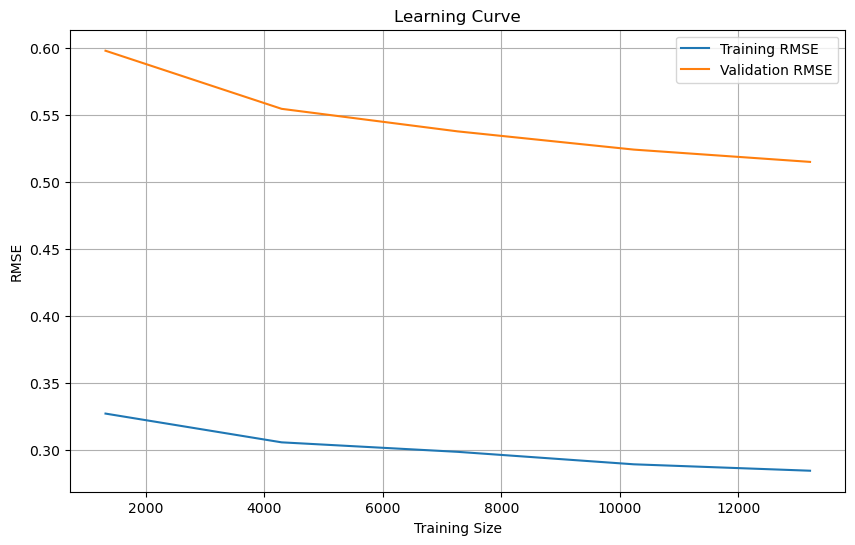

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label="Training RMSE")
plt.plot(train_sizes, val_scores_mean, label="Validation RMSE")
plt.xlabel("Training Size")
plt.ylabel("RMSE")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

## Conclusion
This project demonstrated how different models perform on the task of air quality prediction. While Linear Regression offered a simple baseline, tree-based models like Random Forest and XGBoost provided superior accuracy. After tuning, we achieved a strong K-Fold MAE of ~0.3377, indicating reliable predictive performance.

Hyperparameter tuning played a critical role in boosting model effectiveness. The combination of RandomizedSearchCV and Optuna allowed for efficient exploration of parameter space.

In conclusion, tree-based ensemble methods, when tuned properly, are highly effective for predicting complex environmental outcomes like AQI, and learning curves helped validate our choices and ensure generalizability.